In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset from the correct path
df = pd.read_csv(r"C:\Users\Neethu\Documents\ML\archive\hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Dataset Shape: (217, 32)

----- CENTRAL TENDENCY -----
Mean: 63.79373271889401
Median: 48.0
Mode: 36.0


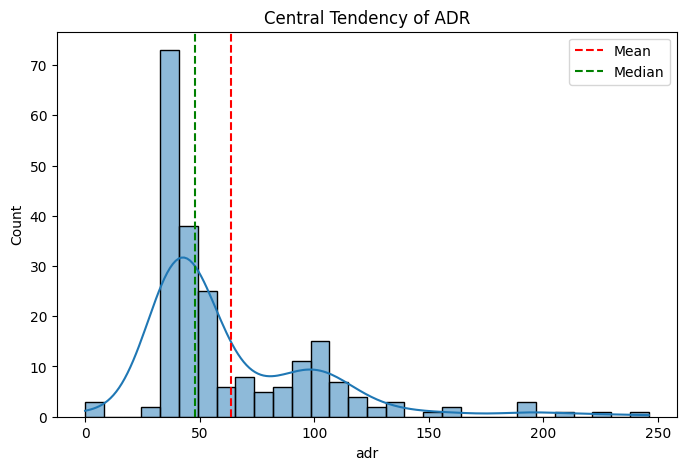


----- OUTLIERS -----
Number of Outliers: 10
       adr
151  189.0
152  246.0
153  224.0
154  212.6
167  163.4


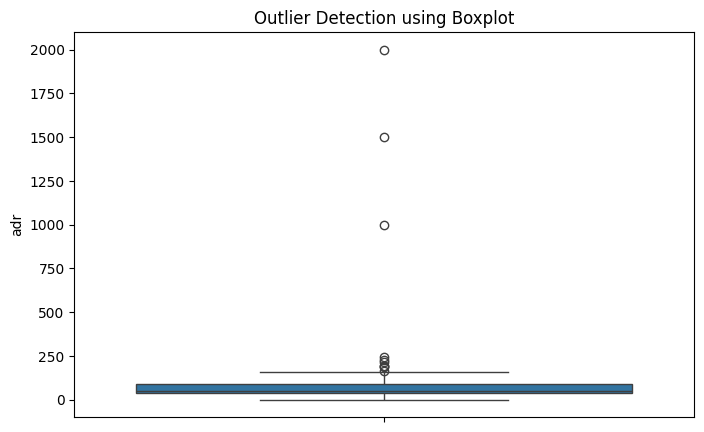

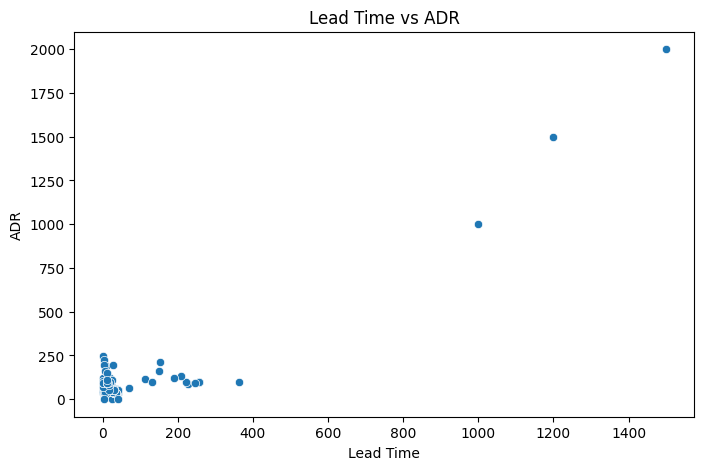


Correlation:
0.9103335829535049


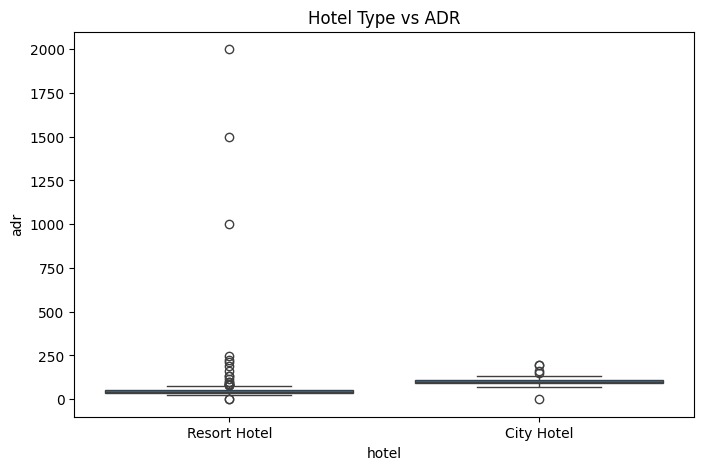


Average ADR by Hotel Type
hotel
City Hotel      106.207447
Resort Hotel     77.176243
Name: adr, dtype: float64

Cross Tabulation
customer_type  Contract  Group  Transient  Transient-Party
hotel                                                     
City Hotel            2      2         30               13
Resort Hotel          3      6         30              134


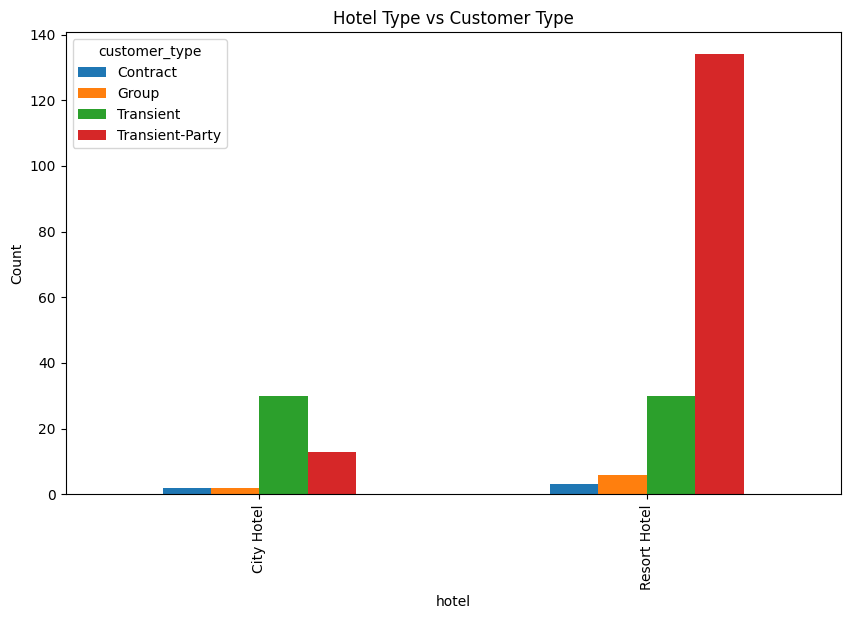

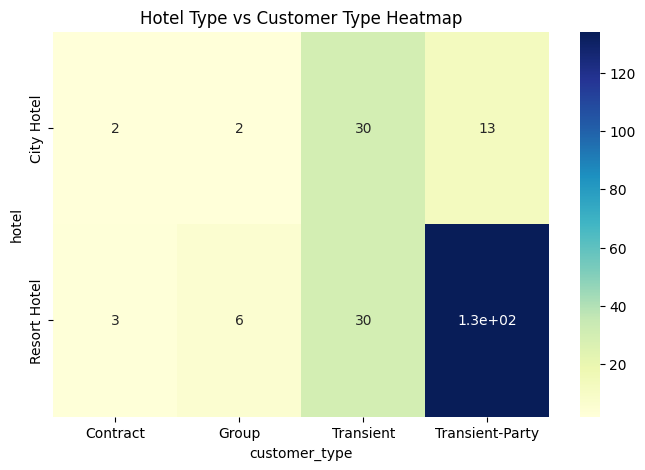

In [5]:
df = df.dropna()

print("Dataset Shape:", df.shape)

column = "adr"  # Average Daily Rate

print("\n----- CENTRAL TENDENCY -----")
print("Mean:", df[column].mean())
print("Median:", df[column].median())
print("Mode:", df[column].mode()[0])

plt.figure(figsize=(8,5))
sns.histplot(df[column], bins=30, kde=True)

plt.axvline(df[column].mean(),
            color='red',
            linestyle='--',
            label='Mean')

plt.axvline(df[column].median(),
            color='green',
            linestyle='--',
            label='Median')

plt.title("Central Tendency of ADR")
plt.legend()
plt.show()


outlier_rows = pd.DataFrame({
    'hotel':['Resort Hotel']*3,
    'lead_time':[1000,1200,1500],
    'arrival_date_year':[2017]*3,
    'arrival_date_month':['August']*3,
    'arrival_date_week_number':[35]*3,
    'arrival_date_day_of_month':[15]*3,
    'stays_in_weekend_nights':[2]*3,
    'stays_in_week_nights':[5]*3,
    'adults':[2]*3,
    'children':[0]*3,
    'babies':[0]*3,
    'meal':['BB']*3,
    'country':['PRT']*3,
    'market_segment':['Online TA']*3,
    'distribution_channel':['TA/TO']*3,
    'is_repeated_guest':[0]*3,
    'previous_cancellations':[0]*3,
    'previous_bookings_not_canceled':[0]*3,
    'reserved_room_type':['A']*3,
    'assigned_room_type':['A']*3,
    'booking_changes':[0]*3,
    'deposit_type':['No Deposit']*3,
    'agent':[1]*3,
    'company':[1]*3,
    'days_in_waiting_list':[0]*3,
    'customer_type':['Transient']*3,
    'adr':[1000,1500,2000],
    'required_car_parking_spaces':[0]*3,
    'total_of_special_requests':[0]*3,
    'reservation_status':['Check-Out']*3,
    'reservation_status_date':['2017-08-15']*3
})

df = pd.concat([df, outlier_rows], ignore_index=True)

Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['adr'] < lower) | (df['adr'] > upper)]

print("\n----- OUTLIERS -----")
print("Number of Outliers:", len(outliers))
print(outliers[['adr']].head())

plt.figure(figsize=(8,5))
sns.boxplot(y=df['adr'])
plt.title("Outlier Detection using Boxplot")
plt.show()


plt.figure(figsize=(8,5))
sns.scatterplot(
    x='lead_time',
    y='adr',
    data=df
)

plt.title("Lead Time vs ADR")
plt.xlabel("Lead Time")
plt.ylabel("ADR")
plt.show()

correlation = df['lead_time'].corr(df['adr'])

print("\nCorrelation:")
print(correlation)

plt.figure(figsize=(8,5))
sns.boxplot(
    x='hotel',
    y='adr',
    data=df
)

plt.title("Hotel Type vs ADR")
plt.show()

print("\nAverage ADR by Hotel Type")
print(df.groupby('hotel')['adr'].mean())


cross_tab = pd.crosstab(
    df['hotel'],
    df['customer_type']
)

print("\nCross Tabulation")
print(cross_tab)

cross_tab.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Hotel Type vs Customer Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(
    cross_tab,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Hotel Type vs Customer Type Heatmap")
plt.show()